# Perceptron from Scratch

## Objective

Implement the original perceptron algorithm from scratch using NumPy for binary classification.

## Topics

- Data preprocessing
- Parameter initialization
- Linear decision boundary
- Step activation function
- Perceptron learning rule
- Prediction
- Accuracy evaluation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from tqdm import tqdm
from sklearn.datasets import make_blobs

In [2]:
def preprocess(X):
    X = X.reshape(X.shape[0], -1)
    X = X / 255.0
    return X

In [3]:
def initialize_parameters(X):
    W = np.random.randn(X.shape[1], 1) * 0.01
    b = 0.0
    return W, b

In [4]:
def model(X, W, b):
    Z = X.dot(W) + b
    return (Z > 0).astype(int)

In [20]:
    train_accs = []
    test_accs = []

In [21]:
def perceptron(X_train,y_train,X_test,y_test,lr=0.01,nb_iter=1500):
    W, b = initialize_parameters(X_train)

    for epoch in tqdm(range(nb_iter)):
        for xi, yi in zip(X_train, y_train):
            xi = xi.reshape(1, -1)
            z = xi.dot(W) + b
            y_pred = 1 if z > 0 else 0
            error = yi - y_pred
            W += lr * error * xi.T
            b += lr * error

        train_pred = predict(X_train, W, b)
        test_pred = predict(X_test, W, b)
        train_accs.append(accuracy_score(y_train, train_pred))
        test_accs.append(accuracy_score(y_test, test_pred))

    return W, b

In [22]:
def predict(X, W, b):

    Z = X.dot(W) + b

    return (Z > 0).astype(int)

100%|█████████████████████████████████████████████████████████████████████████████| 1500/1500 [00:04<00:00, 369.92it/s]


Train Accuracy: 0.97
Test Accuracy: 1.0


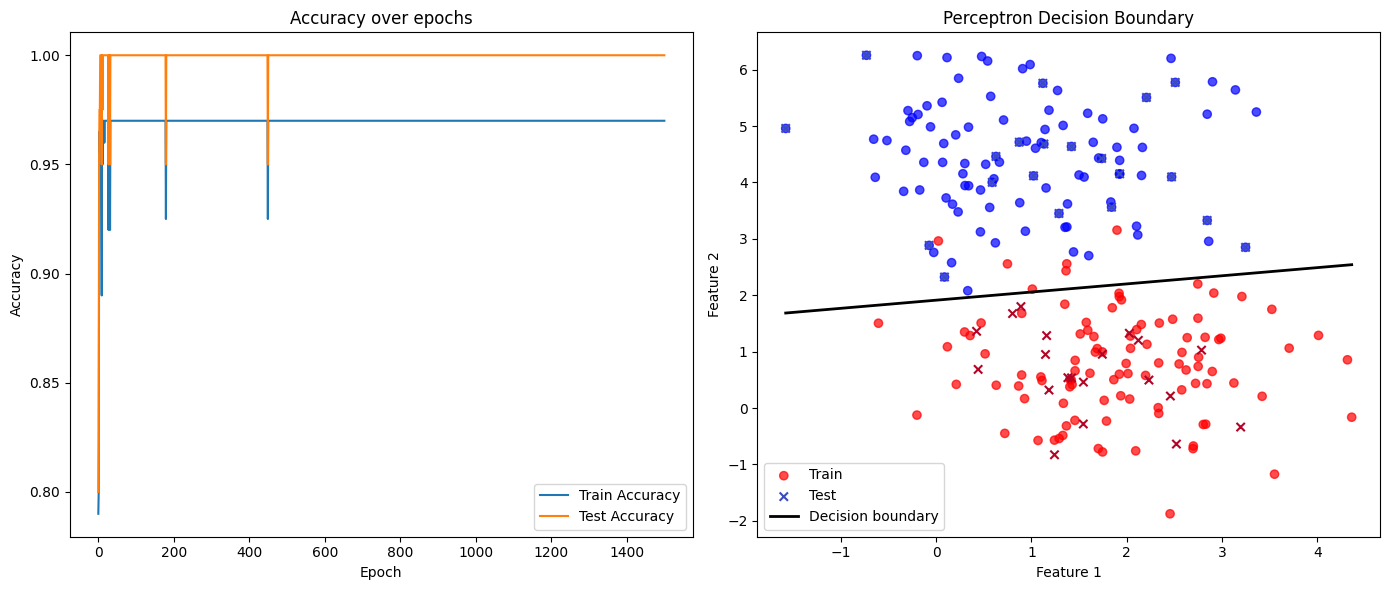

In [23]:
X_train, y_train = make_blobs(n_samples=200, n_features=2, centers=2, random_state=0)
X_test, y_test = make_blobs(n_samples=40, n_features=2, centers=2, random_state=0)

y_train = y_train.reshape((y_train.shape[0], 1))
y_test = y_test.reshape((y_test.shape[0], 1))
W, b = perceptron(X_train, y_train,X_test,y_test)

y_pred_train = predict(X_train, W, b)
y_pred_test  = predict(X_test, W, b)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
fig, axes = plt.subplots(1, 2, figsize=(14,6))

#Accuracy graph 
axes[0].plot(range(len(train_accs)), train_accs, label="Train Accuracy")
axes[0].plot(range(len(test_accs)), test_accs, label="Test Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].set_title("Accuracy over epochs")

#Decision Boundary graph
axes[1].scatter(X_train[:,0], X_train[:,1], c=y_train.ravel(), cmap="bwr", alpha=0.7, label="Train")
axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test.ravel(), cmap="coolwarm", marker="x", label="Test")
x_values = np.linspace(X_train[:,0].min(), X_train[:,0].max(), 100)
y_values = -(W[0]/W[1]) * x_values - b/W[1]
axes[1].plot(x_values, y_values, color="black", linewidth=2, label="Decision boundary")

axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()
axes[1].set_title("Perceptron Decision Boundary")

plt.tight_layout()
plt.show()

The Perceptron was successfully implemented from scratch using NumPy, achieving **97% training accuracy** and **100% test accuracy**. Since the dataset was generated with `make_blobs` (2 features, 2 classes), the task is relatively simple and nearly linearly separable, making it well suited for the Perceptron.